# Validation:
BOS → predicts A

BOS A → predicts B

BOS A B → predicts C

BOS A B C → predicts D

Where the input is always the true sequence.
# Free generation
BOS → predicts A

BOS A → predicts B

BOS A B → predicts X   ← mistake!!

BOS A B X → predicts Y

BOS A B X Y → predicts Z

At this point it is operating in a distribution it did not see during training. That's the type of behavior we want to diagnose.

Let's look at the different questions the following functions respond to:

- `validate()`: "How good is my next-token prediction?"

- `teacher_forced_reconstruction()`: "What image do my next-token predictions corresponds to?"

- `generate_and_visualize_textures()`: "What happens when my model generates a complete sequence on its own?"

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import numpy as np
import math
import sys

In [3]:
REPO_DIR = '/content/Texture_synthesis'
os.chdir('/content')

if not os.path.exists(REPO_DIR):
  !git clone https://github.com/ValentinaEmili/Texture-synthesis.git Texture_synthesis

if REPO_DIR not in sys.path:
  sys.path.append(REPO_DIR)

Cloning into 'Texture_synthesis'...
remote: Enumerating objects: 294, done.
remote: Counting objects: 100% (294/294), done.
remote: Compressing objects: 100% (278/278), done.
remote: Total 294 (delta 125), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (294/294), 46.86 MiB | 13.00 MiB/s, done.
Resolving deltas: 100% (125/125), done.


In [4]:
!pip install import-ipynb -q
import import_ipynb
from Texture_synthesis.codebook.VQ_VAE import VQ_VAE
from Texture_synthesis.generation.Transformers.Transformers import Transformer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 50.5 MB/s eta 0:00:00


In [5]:
train_transform = transforms.Compose([
        transforms.Resize(512),
        transforms.RandomCrop(512),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

eval_transform = transforms.Compose([
        transforms.Resize(512),
        transforms.CenterCrop(512),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])


class DTD_Dataset(Dataset):
    def __init__(self, root, file_list, transform=None, class_to_idx=None):
        self.root = root
        self.transform = transform

        with open(file_list, mode='r', encoding='utf-8') as f:
            self.files = [line.strip() for line in f if line.strip()]

        if class_to_idx is None:
          unique_classes = sorted({os.path.normpath(p).split(os.sep)[0] for p in self.files})
          self.class_to_idx = {class_name: i for i, class_name in enumerate(unique_classes)}
        else:
          self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        relative_path = self.files[idx]
        image_path = os.path.join(self.root, relative_path)
        img = Image.open(image_path).convert('RGB')
        rel_norm = os.path.normpath(relative_path)
        string_label = rel_norm.split(os.sep, 1)[0]
        label = self.class_to_idx[string_label]

        if self.transform:
            img = self.transform(img)

        return img, label

In [6]:
batch_size = 8
path_images = "drive/MyDrive/DeepLearning/dtd/images"
path_labels = "drive/MyDrive/DeepLearning/dtd/labels"
train_dataset = DTD_Dataset(path_images, os.path.join(path_labels, "train1.txt"), train_transform)
class_to_idx = train_dataset.class_to_idx
val_dataset = DTD_Dataset(path_images, os.path.join(path_labels, "val1.txt"), eval_transform, class_to_idx=class_to_idx)
test_dataset = DTD_Dataset(path_images, os.path.join(path_labels, "test1.txt"), eval_transform, class_to_idx=class_to_idx)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transformer = Transformer(num_embeddings=512, seq_len=1024, n_layers=8).to(device)

quant_save_path = '/content/drive/MyDrive/DeepLearning/dtd/checkpoints/vq_vae/epoch_39.pth'
quantizer = VQ_VAE().to(device)
quantizer.load_state_dict(torch.load(quant_save_path, weights_only=True))

optimizer = optim.Adam(transformer.parameters(), lr=2e-4, betas=(0.9, 0.999))
save_path = '/content/drive/MyDrive/DeepLearning/dtd/checkpoints/transformers'

In [8]:
@torch.no_grad()
def extract_codebook_indices(quantizer, data):
  quantizer.eval()

  embedding_dim = quantizer.vq.embedding_dim
  embeddings = quantizer.vq.embeddings.weight                               # (num_embeddings, embed_dim)

  z = quantizer.encoder(data)                                               # (batch_size, embed_dim, h, w)
  z_flattened = z.permute(0, 2, 3, 1).contiguous().view(-1, embedding_dim)  # (batch_size * h * w, embed_dim)

  distances = (torch.sum(z_flattened**2, dim=1, keepdim=True)
                    + torch.sum(embeddings**2, dim=1)
                    - 2 * torch.matmul(z_flattened, embeddings.t()))        # (batch_size * h * w, num_embeddings)

  indices = torch.argmin(distances, dim=1)        # (batch_size * h * w)
  return indices.reshape(z.shape[0],-1)           # (batch_size, seq_len)

## Training and validation

In [ ]:
@torch.no_grad()
def validate(val_loader, transformer, quantizer, device):
  transformer.eval()
  quantizer.eval()

  transformer.to(device)
  quantizer.to(device)

  bos_token_id = transformer.num_embeddings

  total_loss, total_accuracy, total_perplexity = 0.0, 0.0, 0.0

  for batch_idx, (data, _) in enumerate(val_loader):
    data = data.to(device)

    indices = extract_codebook_indices(quantizer, data)
    b, t = indices.shape                      # (batch_size, seq_len)

    bos_tokens = torch.full((b, 1), bos_token_id, dtype=torch.long, device=device)
    full_sequence = torch.cat([bos_tokens, indices], dim=1) # (batch_size, seq_len)

    inputs = full_sequence[:, :-1]            # [BOS, c1, c2, ..., c_{t-1}]
    targets = full_sequence[:, 1:]            # [c1, c2, ..., c_{t-1}, c_{t}]

    logits = transformer(inputs)              # (batch_size, seq_len, num_embeddings)

    predictions = torch.argmax(logits, dim=-1)
    accuracy = (predictions == targets).float().mean() * 100

    targets = targets.reshape(-1)                             # (batch_size * seq_len)
    logits = logits.reshape(-1, transformer.num_embeddings) # (batch_size * seq_len, num_embeddings)

    loss = F.cross_entropy(logits, targets)

    perplexity = torch.exp(loss)

    total_loss += loss.item()
    total_accuracy += accuracy.item()
    total_perplexity += perplexity.item()

  return total_loss, total_accuracy, total_perplexity

In [ ]:
def train_and_validation(train_loader, val_loader, transformer, quantizer, optimizer, device, epochs=20):
  transformer.to(device)
  quantizer.to(device)

  bos_token_id = transformer.num_embeddings
  os.makedirs(save_path, exist_ok=True)

  for epoch in range(epochs):
    transformer.train()
    quantizer.eval()
    total_loss, total_accuracy, total_perplexity = 0.0, 0.0, 0.0

    for batch_idx, (data, _) in enumerate(train_loader):
      data = data.to(device)

      indices = extract_codebook_indices(quantizer, data)
      b, t = indices.shape                      # (batch_size, seq_len)

      bos_tokens = torch.full((b, 1), bos_token_id, dtype=torch.long, device=device)
      full_sequence = torch.cat([bos_tokens, indices], dim=1) # (batch_size, seq_len)

      inputs = full_sequence[:, :-1]            # [BOS, c1, c2, ..., c_{t-1}]
      targets = full_sequence[:, 1:]            # [c1, c2, ..., c_{t-1}, c_{t}]

      logits = transformer(inputs)              # (batch_size, seq_len, num_embeddings)

      predictions = torch.argmax(logits, dim=-1)
      accuracy = (predictions == targets).float().mean() * 100

      optimizer.zero_grad()

      targets = targets.reshape(-1)                             # (batch_size * seq_len)
      logits = logits.reshape(-1, transformer.num_embeddings) # (batch_size * seq_len, num_embeddings)

      loss = F.cross_entropy(logits, targets)

      perplexity = torch.exp(loss)

      loss.backward()
      optimizer.step()

      total_loss += loss.item()
      total_accuracy += accuracy.item()
      total_perplexity += perplexity.item()
    print(f"====> Epoch {epoch} Finished")
    print(f"====> Train Loss: {(total_loss / len(train_loader)):.4f} | Train Accuracy: {(total_accuracy / len(train_loader)):.4f} | Train Perplexity: {total_perplexity/len(train_loader):.2f}")

    epoch_save_path = os.path.join(save_path, f"epoch_{epoch}.pth")
    #torch.save(transformer.state_dict(), epoch_save_path)

    total_loss, total_accuracy, total_perplexity = validate(val_loader, transformer, quantizer, device)
    print(f"====> Valid Loss: {(total_loss / len(val_loader)):.4f} | Valid Accuracy: {(total_accuracy / len(val_loader)):.4f} | Valid Perplexity: {total_perplexity/len(val_loader):.2f}\n")

In [ ]:
train_and_validation(train_loader, val_loader, transformer, quantizer, optimizer, device, epochs=30)

====> Epoch 0 Finished
====> Train Loss: 3.4970 | Train Accuracy: 15.5519 | Train Perplexity: 42.88
====> Valid Loss: 3.0560 | Valid Accuracy: 19.7345 | Valid Perplexity: 21.53

====> Epoch 1 Finished
====> Train Loss: 3.0123 | Train Accuracy: 20.1826 | Train Perplexity: 20.47
====> Valid Loss: 2.9698 | Valid Accuracy: 20.5829 | Valid Perplexity: 19.86

====> Epoch 2 Finished
====> Train Loss: 2.9543 | Train Accuracy: 20.7582 | Train Perplexity: 19.32
====> Valid Loss: 2.9316 | Valid Accuracy: 20.9409 | Valid Perplexity: 19.16

====> Epoch 3 Finished
====> Train Loss: 2.9149 | Train Accuracy: 21.1834 | Train Perplexity: 18.58
====> Valid Loss: 2.9017 | Valid Accuracy: 21.3458 | Valid Perplexity: 18.63

====> Epoch 4 Finished
====> Train Loss: 2.8944 | Train Accuracy: 21.4422 | Train Perplexity: 18.22
====> Valid Loss: 2.8869 | Valid Accuracy: 21.5979 | Valid Perplexity: 18.38

====> Epoch 5 Finished
====> Train Loss: 2.8756 | Train Accuracy: 21.6995 | Train Perplexity: 17.89
====> Vali

- temperature < 1.0: generation is more conservative
- temperature > 1.0: it produces more diversity, but potentially more garbage

In [23]:
@torch.no_grad()
def generate_and_visualize_textures(transformer, quantizer, device, batch_size=4, seq_len=1024, temperature=0.8, top_k=None, grid_size=(1, 4)):
  transformer.eval()
  quantizer.eval()

  transformer.to(device)
  quantizer.to(device)

  h_lat, w_lat = 32, 32 # 32x32=1024
  embeddings = quantizer.vq.embeddings.weight
  embed_dim = quantizer.vq.embedding_dim
  bos_token_id = transformer.num_embeddings
  sequence = torch.full((batch_size, 1), bos_token_id, dtype=torch.long, device=device)

  with torch.no_grad():
    for _ in range(seq_len):
      logits = transformer(sequence)
      next_token_logits = logits[:, -1, :]                          # (batch_size, num_embeddings)

      next_token_logits /= temperature

      if top_k is not None:
        top_k = min(top_k, next_token_logits.shape[1])
        highest_scores, _ = torch.topk(next_token_logits, top_k, dim=-1)
        threshold = highest_scores[:, -1:]
        next_token_logits[next_token_logits < threshold] = -float('Inf')


      probs = F.softmax(next_token_logits, dim=-1)
      next_token = torch.multinomial(probs, 1)
      sequence = torch.cat([sequence, next_token], dim=1)

    final_indices = sequence[:, 1:]
    z = embeddings[final_indices]
    z = z.view(batch_size, h_lat, w_lat, embed_dim).permute(0, 3, 1, 2).contiguous()
    generated_img = quantizer.decoder(z)
    generated_img = (generated_img + 1.0) / 2.0 # [-1, 1] -> [0, 1]
    generated_img = generated_img.permute(0, 2, 3, 1).cpu()

    rows, cols = grid_size
    figs, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    num_displayed_imgs = min(len(generated_img), len(axes))

    for i in range(num_displayed_imgs):
      axes[i].imshow(generated_img[i])
      axes[i].axis('off')

    plt.show()

Epoch: 29


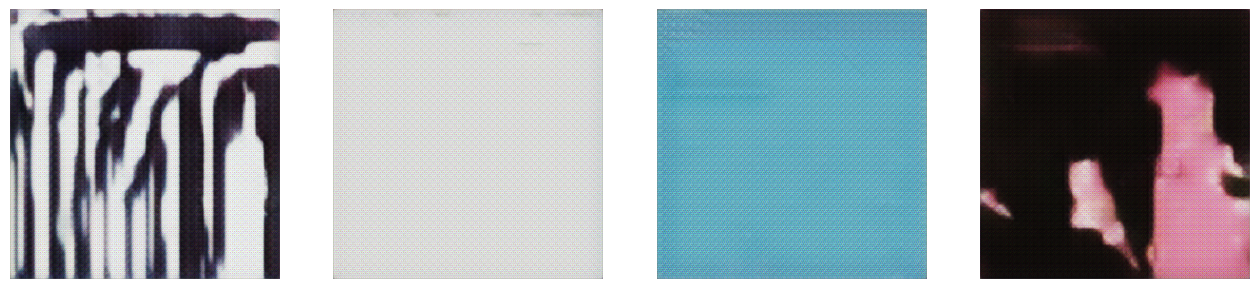

In [27]:
epochs = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transf_save_path = '/content/drive/MyDrive/DeepLearning/dtd/checkpoints/transformers'
transformer = Transformer(num_embeddings=512, seq_len=1024, n_layers=8).to(device)

quant_save_path = '/content/drive/MyDrive/DeepLearning/dtd/checkpoints/vq_vae/epoch_39.pth'
quantizer = VQ_VAE().to(device)
quantizer.load_state_dict(torch.load(quant_save_path, weights_only=True))

temperatures = set(0.7, 0.8, 1.0, 1.2)
top_ks = set(10, 20, 50, 100)

for temperature in temperatures:
  for top_k in top_ks:
  for epoch in range(epochs):
    if epoch == 29:
      print(f"Epoch: {epoch}")
      epoch_save_path = os.path.join(transf_save_path, f"epoch_{epoch}.pth")
      transformer.load_state_dict(torch.load(epoch_save_path, weights_only=True))

      generate_and_visualize_textures(transformer, quantizer, device, top_k=50)


## Teacher forcing
A training strategy used in the development of sequence-to-sequence models, by providing the correct input at each step of the sequence rather than allowing the model to generate the next step based on its previous outputs.

In [19]:
@torch.no_grad()
def teacher_forced_reconstruction(val_loader, transformer, quantizer, device, data):
  transformer.eval()
  quantizer.eval()

  transformer.to(device)
  quantizer.to(device)

  indices = extract_codebook_indices(quantizer, data)
  b, t = indices.shape

  bos_token_id = transformer.num_embeddings
  bos_tokens = torch.full((b, 1), bos_token_id, dtype=torch.long, device=device)
  full_sequence = torch.cat([bos_tokens, indices], dim=1)

  inputs = full_sequence[:, :-1]
  targets = full_sequence[:, 1:]

  logits = transformer(inputs)

  predictions = torch.argmax(logits, dim=-1)

  h_lat, w_lat = 32, 32
  embeddings = quantizer.vq.embeddings.weight
  embed_dim = quantizer.vq.embedding_dim

  z = embeddings[predictions]
  z = z.view(b, h_lat, w_lat, embed_dim).permute(0, 3, 1, 2).contiguous()
  reconstructed = quantizer.decoder(z)
  reconstructed = (reconstructed + 1.0) / 2.0 # [-1, 1] -> [0, 1]
  reconstructed = reconstructed.permute(0, 2, 3, 1).cpu()

  original = data.cpu()
  original = (original + 1.0) / 2.0
  original = original.permute(0, 2, 3, 1)

  fig, axes = plt.subplots(2, batch_size, figsize=(batch_size * 4, 8))

  for i in range(batch_size):
    axes[0, i].imshow(original[i].clamp(0, 1))
    axes[0, i].set_title(f"Original {i+1}")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed[i].clamp(0, 1))
    axes[1, i].set_title(f"Transformer TF {i+1}")
    axes[1, i].axis("off")

  plt.show()

In [ ]:
transf_save_path = '/content/drive/MyDrive/DeepLearning/dtd/checkpoints/transformers'

quant_save_path = '/content/drive/MyDrive/DeepLearning/dtd/checkpoints/vq_vae/epoch_39.pth'
quantizer = VQ_VAE().to(device)
quantizer.load_state_dict(torch.load(quant_save_path, weights_only=True))

for epoch in range(epochs):
  print(f"Epoch: {epoch}")

  transformer = Transformer(num_embeddings=512, seq_len=1024, n_layers=8).to(device)
  epoch_save_path = os.path.join(transf_save_path, f"epoch_{epoch}.pth")
  transformer.load_state_dict(torch.load(epoch_save_path, weights_only=True))

  for batch_idx, (data, _) in enumerate(val_loader):
    data = data.to(device)
    teacher_forced_reconstruction(val_loader, transformer, quantizer,device, data)

In [ ]:
transf_save_path = '/content/drive/MyDrive/DeepLearning/dtd/checkpoints/transformers'

quant_save_path = '/content/drive/MyDrive/DeepLearning/dtd/checkpoints/vq_vae/epoch_39.pth'
quantizer = VQ_VAE().to(device)
quantizer.load_state_dict(torch.load(quant_save_path, weights_only=True))

for epoch in range(epochs):
  if epoch == 29:
    print(f"Epoch: {epoch}")

    transformer = Transformer(num_embeddings=512, seq_len=1024, n_layers=8).to(device)
    epoch_save_path = os.path.join(transf_save_path, f"epoch_{epoch}.pth")
    transformer.load_state_dict(torch.load(epoch_save_path, weights_only=True))

    for batch_idx, (data, _) in enumerate(val_loader):
      data = data.to(device)
      teacher_forced_reconstruction(val_loader, transformer, quantizer,device, data)